# Open-set refusal on EVA02 OOF (inner CV)

Closed-test candidate mode on identity-disjoint 5-fold OOF of LLM2CLIP EVA02-L-14-336 (`runs/cv/eva02_k4_cam`). Raw embeddings, no TTA, no postproc. `camera_id` / `vehicle_id` are labels for building pairs only, never features.

**Protocol (nested 5-fold).** For test fold `f`:

1. **Train packs (50/50).** Same query vs full gallery (`y=1`) and vs that identity stripped (`y=0`). CatBoost and TabM fit on these pairs.
2. **Eval / calibration packs (~20% open).** Hold out 20% of query identities from the gallery (`open_set_pack`). One row per query; prevalence matches the hidden-test mix. Thresholds, F1, TNR, and outer-OOF use only these packs.
3. Inner CV on the other four folds: train CatBoost/TabM on three 50/50 packs, score the fourth eval pack. Cosine needs no fit.
4. Freeze each head's contest operating point (`0.7 × F1 + 0.3 × TNR`) on pooled inner **eval** scores. Rank-average weights and the three-head vote also freeze here.
5. Retrain CatBoost/TabM on all four 50/50 packs and score fold `f`'s eval pack with that fold's inner-CV thresholds. Do not reuse a threshold that saw fold `f`.
6. Outer-OOF concatenates those per-fold accept/refuse masks (one micro TP/FP/FN/TN). Docker submit is CatBoost `eva02_model` (P ≥ 0.5873). The cosine head stays `eva02_threshold`. The two-head AND is not the submit rule.

TNR uses only no-match queries. F1 and TNR are **micro**. F1 is query-level: TP requires a gallery match **and** a correct top-1; a closed query with the wrong top-1 is FP. Candidates below rank-1 do not affect F1 or TNR.

| Head | Score |
| --- | --- |
| Cosine | max query–gallery cosine (`eva02_threshold`) |
| CatBoost | `P(match exists)` (**Docker serving**, `eva02_model`) |
| serving AND | cosine and CatBoost both accept (`eva02_ensemble`, not Docker) |
| TabM | mean sigmoid over `k` BatchEnsemble members |
| rank-mean | equal-weight rank average of cosine, CatBoost, TabM |
| rank-weighted | inner-CV nonnegative weights on those ranks |
| majority | accept if at least two of the three heads accept |
| unanimous | accept only if all three heads accept |

Contest metrics: **`0.7 × F1 + 0.3 × TNR` at the frozen inner-CV threshold**, plus F1, TNR, and PR-AUC on each head's continuous OOF score (max cosine or CatBoost P). That PR-AUC is not the score in `candidates.csv`: serving writes `1 − distance`, and CatBoost only gates which rows appear. Rank-average / TabM / three-head votes stay OOF calibration only.


In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "train.csv").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from postproc.retrieval import normalize
from refusal import (
    OPEN_SET_FRACTION,
    STAT_NAMES,
    balanced_pack,
    candidate_metrics,
    decide,
    decision_metrics,
    feature_names,
    fit_boosting,
    fit_rank_weights,
    fit_tabm,
    open_set_pack,
    open_set_split,
    predict_boosting,
    predict_tabm,
    rank_average,
    ranking_metrics,
    select_threshold,
    similarities,
    sweep_thresholds,
    vote_fraction,
)

plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "axes.grid": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
pd.set_option("display.max_columns", 24)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)


def display(obj):
    print(obj if isinstance(obj, str) else obj.to_string() if hasattr(obj, "to_string") else obj)


CV = ROOT / "runs" / "cv" / "eva02_k4_cam"
FIG_DIR = ROOT / "notebooks" / "eva02" / "refusal_analysis_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
K_RETR = 10
HEADS = ("cosine", "catboost", "tabm")
print("ROOT", ROOT)
print("CV", CV)

ROOT /data/projects/ryzhichkin/ReID
CV /data/projects/ryzhichkin/ReID/runs/cv/eva02_k4_cam


## Load OOF folds: 50/50 train packs and 20% identity-hold-out eval packs


In [3]:
def load_pack(directory):
    oof = pd.read_csv(directory / "oof.csv", dtype={"image_id": str})
    query = pd.read_csv(directory / "query.csv", dtype={"image_id": str})
    gallery = pd.read_csv(directory / "gallery.csv", dtype={"image_id": str})
    emb = normalize(np.load(directory / "embeddings.npy"))
    lookup = {image_id: i for i, image_id in enumerate(oof.image_id)}
    qe = emb[[lookup[i] for i in query.image_id]]
    ge = emb[[lookup[i] for i in gallery.image_id]]
    return {"query": query, "gallery": gallery, "qe": qe, "ge": ge}


FOLDS = {fold: load_pack(CV / f"fold{fold}" / "val") for fold in range(5)}
TRAIN = {}
EVAL = {}
for fold, pack in FOLDS.items():
    qids = pack["query"].vehicle_id.to_numpy()
    gids = pack["gallery"].vehicle_id.to_numpy()
    X, y, cos, top = balanced_pack(
        pack["qe"],
        pack["ge"],
        qids,
        gids,
        k=K_RETR,
        with_embeddings=True,
    )
    eX, ey, ecos, etop, held = open_set_pack(
        pack["qe"],
        pack["ge"],
        qids,
        gids,
        k=K_RETR,
        with_embeddings=True,
        fraction=OPEN_SET_FRACTION,
        seed=fold,
    )
    TRAIN[fold] = {"X": X, "y": y, "cos": cos, "top": top}
    EVAL[fold] = {"X": eX, "y": ey, "cos": ecos, "top": etop, "held": held}
    print(
        fold,
        "train",
        len(y),
        "pos",
        float(y.mean()),
        "eval",
        len(ey),
        "open",
        float(1.0 - ey.mean()),
        "held",
        len(held),
        "top1",
        float(etop[ey.astype(bool)].mean()) if ey.any() else float("nan"),
        "dim",
        X.shape[1],
    )

0 train 618 pos 0.5 eval 309 open 0.20064724919093846 held 62 top1 0.854251012145749 dim 535


1 train 616 pos 0.5 eval 308 open 0.2012987012987013 held 62 top1 0.8333333333333334 dim 535


2 train 616 pos 0.5 eval 308 open 0.2012987012987013 held 62 top1 0.8780487804878049 dim 535


3 train 616 pos 0.5 eval 308 open 0.2012987012987013 held 62 top1 0.8536585365853658 dim 535


4 train 616 pos 0.5 eval 308 open 0.2012987012987013 held 62 top1 0.8983739837398373 dim 535


## Nested 5-fold fit

Inner models see only three of the four training folds (50/50 packs). Thresholds, blend weights, and the serving AND rule freeze on inner **eval** packs and never touch the outer test fold. Each outer fold keeps its own inner-CV accept/refuse mask. `serving_and` applies that fold's cosine and CatBoost thresholds jointly: accept if both heads accept.


In [4]:
def concat_folds(store, folds, key):
    return np.concatenate([store[fold][key] for fold in folds], 0)


def fit_models(train_folds, seed, epochs):
    X, y = concat_folds(TRAIN, train_folds, "X"), concat_folds(TRAIN, train_folds, "y")
    cat = fit_boosting(X, y, iterations=200, depth=4, learning_rate=0.08, seed=seed)
    tabm = fit_tabm(
        X,
        y,
        epochs=epochs,
        batch_size=128,
        patience=6,
        hidden=(64, 32),
        dropout=0.1,
        k=8,
        seed=seed,
        val_frac=0.15,
    )
    return cat, tabm


def predict_fold(cat, tabm, fold):
    return {
        "y": EVAL[fold]["y"],
        "top": EVAL[fold]["top"],
        "cosine": EVAL[fold]["cos"],
        "catboost": predict_boosting(cat, EVAL[fold]["X"]),
        "tabm": predict_tabm(tabm, EVAL[fold]["X"]),
    }


def summarize(name, y, scores, threshold, top):
    return {"method": name, **candidate_metrics(y, scores, threshold, top), **ranking_metrics(y, scores)}


ROWS = []
OOF: dict[str, dict[str, Any]] = {
    name: {"y": [], "top": [], "scores": [], "threshold": [], "accept": []}
    for name in (
        "always_accept",
        "cosine",
        "catboost",
        "serving_and",
        "tabm",
        "rank_mean",
        "rank_weighted",
        "majority",
        "unanimous",
    )
}
BLEND_W = []
MODELS: dict[int, dict[str, Any]] = {}
for test_fold in range(5):
    others = [fold for fold in range(5) if fold != test_fold]
    inner_y = []
    inner_top = []
    inner = {name: [] for name in HEADS}
    for val_fold in others:
        train_inner = [fold for fold in others if fold != val_fold]
        cat_i, tabm_i = fit_models(train_inner, seed=10 * test_fold + val_fold, epochs=12)
        pred_i = predict_fold(cat_i, tabm_i, val_fold)
        inner_y.append(pred_i["y"])
        inner_top.append(pred_i["top"])
        for name in HEADS:
            inner[name].append(pred_i[name])
    y_in = np.concatenate(inner_y)
    top_in = np.concatenate(inner_top)
    s_in = {name: np.concatenate(inner[name]) for name in HEADS}
    t_head = {name: select_threshold(y_in, s_in[name], top_in, kind="contest") for name in HEADS}
    channels_in = [s_in[name] for name in HEADS]
    t_rank = select_threshold(y_in, rank_average(channels_in), top_in, kind="contest")
    weights, t_weighted = fit_rank_weights(y_in, channels_in, top_in, grid=4)
    head_t = [t_head[name]["threshold"] for name in HEADS]
    votes_in = vote_fraction(channels_in, head_t)
    t_vote = select_threshold(y_in, votes_in, top_in, kind="contest")

    cat, tabm = fit_models(others, seed=test_fold, epochs=16)
    ev = predict_fold(cat, tabm, test_fold)
    channels = [ev[name] for name in HEADS]
    rank = rank_average(channels)
    rank_w = rank_average(channels, weights=weights)
    votes = vote_fraction(channels, head_t)
    methods = {
        "always_accept": (ev["cosine"], -1.0, decide(ev["cosine"], -1.0)),
        "cosine": (ev["cosine"], t_head["cosine"]["threshold"], None),
        "catboost": (ev["catboost"], t_head["catboost"]["threshold"], None),
        "tabm": (ev["tabm"], t_head["tabm"]["threshold"], None),
        "rank_mean": (rank, t_rank["threshold"], None),
        "rank_weighted": (rank_w, t_weighted["threshold"], None),
        "majority": (votes, 2.0 / 3.0, None),
        "unanimous": (votes, 1.0, None),
    }
    serving_accept = decide(ev["cosine"], t_head["cosine"]["threshold"]) & decide(
        ev["catboost"], t_head["catboost"]["threshold"]
    )
    methods["serving_and"] = (np.minimum(ev["cosine"], ev["catboost"]), float("nan"), serving_accept)
    print(
        f"fold {test_fold}: eval {len(ev['y'])} open {float(1.0 - ev['y'].mean()):.3f} "
        f"inner {len(y_in)} weights {np.round(weights, 3)} vote-t {t_vote['threshold']:.2f}"
    )
    MODELS[test_fold] = {"catboost": cat, "tabm": tabm, "eval": ev, "t_head": t_head, "weights": weights}
    BLEND_W.append(weights)
    for name, (pred, thr, accept) in methods.items():
        mask = decide(pred, thr) if accept is None else accept
        row = {
            "method": name,
            **decision_metrics(ev["y"].astype(bool), mask, ev["top"]),
            **ranking_metrics(ev["y"], pred),
            "threshold": thr,
        }
        row["fold"] = test_fold
        ROWS.append(row)
        OOF[name]["y"].append(ev["y"])
        OOF[name]["top"].append(ev["top"])
        OOF[name]["scores"].append(pred)
        OOF[name]["threshold"].append(thr)
        OOF[name]["accept"].append(mask)

for name in OOF:
    OOF[name]["y"] = np.concatenate(OOF[name]["y"])
    OOF[name]["top"] = np.concatenate(OOF[name]["top"])
    OOF[name]["scores"] = np.concatenate(OOF[name]["scores"])
    OOF[name]["accept"] = np.concatenate(OOF[name]["accept"])

table = pd.DataFrame(ROWS)
cols = [
    "fold",
    "method",
    "threshold",
    "contest",
    "f1",
    "precision",
    "recall",
    "tnr",
    "fp_closed",
    "pr_auc",
    "n_open",
    "n_closed",
]
display(table[cols])

fold 0: eval 309 open 0.201 inner 1232 weights [0.375 0.25  0.375] vote-t 0.67


fold 1: eval 308 open 0.201 inner 1233 weights [0.75 0.25 0.  ] vote-t 0.67


fold 2: eval 308 open 0.201 inner 1233 weights [0.  0.6 0.4] vote-t 0.33


fold 3: eval 308 open 0.201 inner 1233 weights [0. 1. 0.] vote-t 0.67


fold 4: eval 308 open 0.201 inner 1233 weights [0.25 0.75 0.  ] vote-t 0.67
    fold         method  threshold  contest     f1  precision  recall    tnr  fp_closed  pr_auc  n_open  n_closed
0      0  always_accept    -1.0000   0.5681 0.8115     0.6828  1.0000 0.0000         36  0.9579      62       247
1      0         cosine     0.7935   0.8050 0.7906     0.8317  0.7534 0.8387         24  0.9579      62       247
2      0       catboost     0.5697   0.7949 0.7692     0.8290  0.7175 0.8548         24  0.9670      62       247
3      0           tabm     0.4350   0.8018 0.8136     0.8211  0.8063 0.7742         25  0.9685      62       247
4      0      rank_mean     0.2857   0.8087 0.8304     0.8230  0.8378 0.7581         25  0.9673      62       247
5      0  rank_weighted     0.2875   0.8068 0.8277     0.8222  0.8333 0.7581         25  0.9668      62       247
6      0       majority     0.6667   0.7989 0.7887     0.8276  0.7534 0.8226         24  0.9372      62       247
7      0    

## Aggregate contest metrics

Mean ± std over the five outer folds (each fold uses only its inner-CV threshold, on that fold's 20% identity-hold-out pack). Outer-OOF micro metrics concatenate those decisions; they do not re-apply a pooled threshold. Serving is the mean inner-CV **cosine** threshold (best nested contest score). `serving_and/oof` is cosine AND CatBoost with per-fold inner thresholds, kept as a comparison. Always-accept TNR is 0. F1 penalizes a closed query whose top-1 identity is wrong.


In [5]:
order = [
    "always_accept",
    "cosine",
    "catboost",
    "serving_and",
    "tabm",
    "rank_mean",
    "rank_weighted",
    "majority",
    "unanimous",
]
agg = (
    table.groupby("method")[["contest", "f1", "precision", "recall", "tnr", "pr_auc", "threshold"]]
    .agg(["mean", "std"])
    .loc[order]
)
display(agg)

pooled_rows = []
deploy_rows = []
for name in order:
    y = OOF[name]["y"]
    top = OOF[name]["top"]
    scores = OOF[name]["scores"]
    row = {
        "method": name + "/oof",
        **decision_metrics(y, OOF[name]["accept"], top),
        **ranking_metrics(y, scores),
    }
    pooled_rows.append(row)
    deploy_t = float(np.nanmean(OOF[name]["threshold"]))
    if name == "serving_and":
        cos_t = float(np.mean(OOF["cosine"]["threshold"]))
        cb_t = float(np.mean(OOF["catboost"]["threshold"]))
        deploy_accept = decide(OOF["cosine"]["scores"], cos_t) & decide(OOF["catboost"]["scores"], cb_t)
        deploy = {
            "method": name + "/deploy_t",
            **decision_metrics(y, deploy_accept, top),
            **ranking_metrics(y, scores),
            "threshold": float("nan"),
        }
    else:
        deploy = summarize(name + "/deploy_t", y, scores, deploy_t, top)
    deploy_rows.append(deploy)
pooled = pd.DataFrame(pooled_rows)
deploy = pd.DataFrame(deploy_rows)
display(
    pooled[
        ["method", "contest", "f1", "precision", "recall", "tnr", "fp_closed", "pr_auc", "n_open", "n_closed"]
    ]
)
display(deploy[["method", "threshold", "contest", "f1", "tnr"]])
print("blend weights mean", np.round(np.mean(BLEND_W, 0), 3), "std", np.round(np.std(BLEND_W, 0), 3))
print(
    "serving cosine",
    round(float(np.mean(OOF["cosine"]["threshold"])), 4),
    "catboost",
    round(float(np.mean(OOF["catboost"]["threshold"])), 4),
)

              contest            f1        precision        recall           tnr        pr_auc        threshold       
                 mean    std   mean    std      mean    std   mean    std   mean    std   mean    std      mean    std
method                                                                                                                
always_accept  0.5714 0.0098 0.8163 0.0140    0.6898 0.0200 1.0000 0.0000 0.0000 0.0000 0.9515 0.0090   -1.0000 0.0000
cosine         0.8102 0.0183 0.8187 0.0243    0.8332 0.0235 0.8054 0.0368 0.7903 0.0456 0.9515 0.0090    0.7868 0.0041
catboost       0.8114 0.0239 0.8121 0.0293    0.8389 0.0307 0.7884 0.0464 0.8097 0.0552 0.9636 0.0088    0.5873 0.0404
serving_and    0.8111 0.0259 0.8020 0.0308    0.8423 0.0295 0.7663 0.0431 0.8323 0.0505 0.9644 0.0071       NaN    NaN
tabm           0.8053 0.0143 0.8256 0.0317    0.8264 0.0286 0.8288 0.0719 0.7581 0.0684 0.9647 0.0049    0.4779 0.0602
rank_mean      0.8146 0.0110 0.8264 0.0172    0.

/tmp/ipykernel_386737/2195580495.py:31: RuntimeWarning: Mean of empty slice
  deploy_t = float(np.nanmean(OOF[name]["threshold"]))


## Inner-CV cosine threshold (fold 0)

The sweep below is the inner OOF of fold 0's training folds **eval packs** (20% identity hold-out). The vertical line is the frozen contest point (`0.7 × F1 + 0.3 × TNR`) applied to fold 0's eval pack. F1 uses contest top-1 identity, not pair-level hits. max-F1 / Youden / F1×TNR are shown only as alternate rules.


      rule  threshold  cal_contest  cal_f1  cal_tnr  contest     f1    tnr  precision  recall  fp_closed
0  contest     0.7935       0.8183  0.8217   0.8105   0.8050 0.7906 0.8387     0.8317  0.7534         24
1   max_f1     0.7007       0.7872  0.8620   0.6129   0.8081 0.8503 0.7097     0.8066  0.8991         29
2   youden     0.7935       0.8183  0.8217   0.8105   0.8050 0.7906 0.8387     0.8317  0.7534         24
3   f1_tnr     0.8373       0.7979  0.7580   0.8911   0.7486 0.6823 0.9032     0.8239  0.5822         22


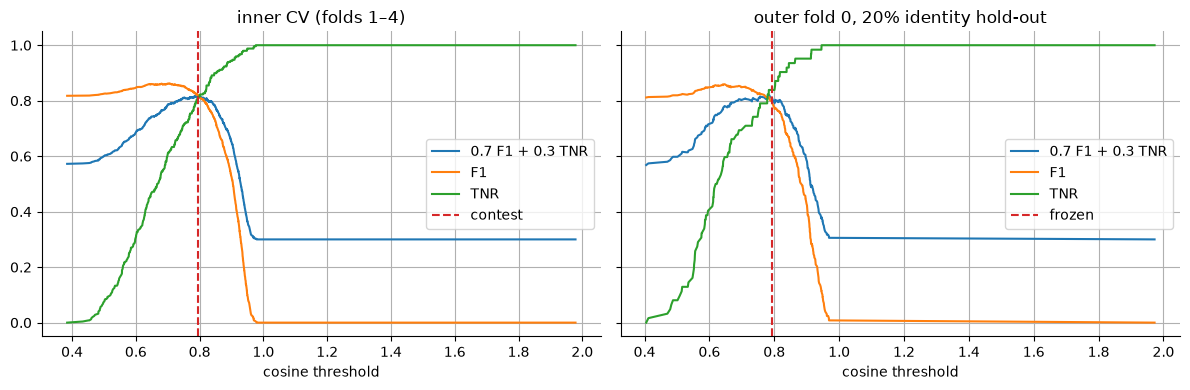

In [6]:
fold0_others = [1, 2, 3, 4]
inner_y = []
inner_cos = []
inner_top = []
for val_fold in fold0_others:
    inner_y.append(EVAL[val_fold]["y"])
    inner_cos.append(EVAL[val_fold]["cos"])
    inner_top.append(EVAL[val_fold]["top"])
y_in = np.concatenate(inner_y)
cos_in = np.concatenate(inner_cos)
top_in = np.concatenate(inner_top)
y0 = EVAL[0]["y"]
cos0 = EVAL[0]["cos"]
top0 = EVAL[0]["top"]
rules = {
    "contest": select_threshold(y_in, cos_in, top_in, kind="contest"),
    "max_f1": select_threshold(y_in, cos_in, top_in, kind="max_f1"),
    "youden": select_threshold(y_in, cos_in, top_in, kind="youden"),
    "f1_tnr": select_threshold(y_in, cos_in, top_in, kind="f1_tnr"),
}
rule_tab = []
for name, picked in rules.items():
    row = candidate_metrics(y0, cos0, picked["threshold"], top0)
    row["rule"] = name
    row["cal_contest"] = picked["contest"]
    row["cal_f1"] = picked["f1"]
    row["cal_tnr"] = picked["tnr"]
    rule_tab.append(row)
display(
    pd.DataFrame(rule_tab)[
        [
            "rule",
            "threshold",
            "cal_contest",
            "cal_f1",
            "cal_tnr",
            "contest",
            "f1",
            "tnr",
            "precision",
            "recall",
            "fp_closed",
        ]
    ]
)

sweep_cal = pd.DataFrame(sweep_thresholds(y_in, cos_in, top_in))
sweep_ev = pd.DataFrame(sweep_thresholds(y0, cos0, top0))
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
ax[0].plot(sweep_cal.threshold, sweep_cal.contest, label="0.7 F1 + 0.3 TNR")
ax[0].plot(sweep_cal.threshold, sweep_cal.f1, label="F1")
ax[0].plot(sweep_cal.threshold, sweep_cal.tnr, label="TNR")
ax[0].axvline(rules["contest"]["threshold"], color="C3", ls="--", label="contest")
ax[0].set_title("inner CV (folds 1–4)")
ax[0].set_xlabel("cosine threshold")
ax[0].legend()
ax[1].plot(sweep_ev.threshold, sweep_ev.contest, label="0.7 F1 + 0.3 TNR")
ax[1].plot(sweep_ev.threshold, sweep_ev.f1, label="F1")
ax[1].plot(sweep_ev.threshold, sweep_ev.tnr, label="TNR")
ax[1].axvline(rules["contest"]["threshold"], color="C3", ls="--", label="frozen")
ax[1].set_title("outer fold 0, 20% identity hold-out")
ax[1].set_xlabel("cosine threshold")
ax[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "threshold_sweep.png", dpi=140, bbox_inches="tight")
plt.show()

Saved figure:

![threshold sweep](refusal_analysis_figs/threshold_sweep.png)


## Score separation on pooled OOF pairs


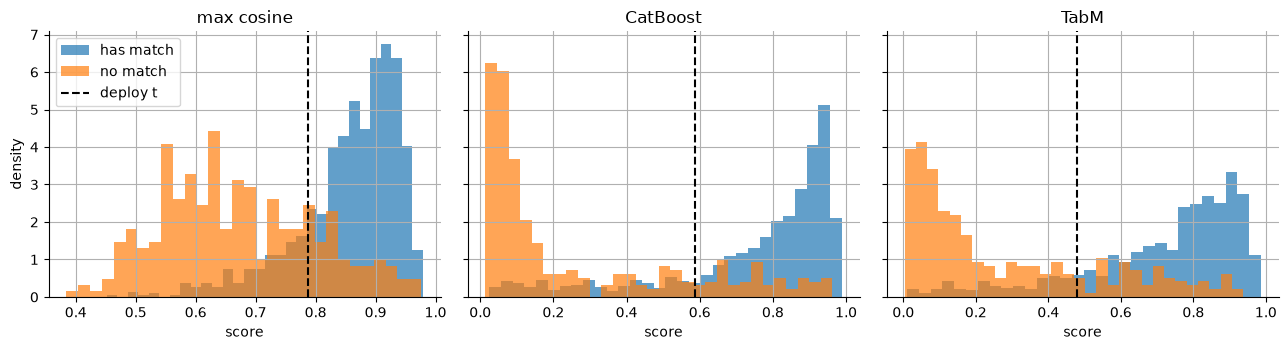

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, name, title in zip(axes, HEADS, ("max cosine", "CatBoost", "TabM"), strict=True):
    y = OOF[name]["y"].astype(bool)
    s = OOF[name]["scores"]
    ax.hist(s[y], bins=30, alpha=0.7, label="has match", density=True)
    ax.hist(s[~y], bins=30, alpha=0.7, label="no match", density=True)
    ax.axvline(np.mean(OOF[name]["threshold"]), color="k", ls="--", label="deploy t")
    ax.set_title(title)
    ax.set_xlabel("score")
axes[0].set_ylabel("density")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "score_hist.png", dpi=140, bbox_inches="tight")
plt.show()

Saved figure:

![score histograms](refusal_analysis_figs/score_hist.png)


## Precision–recall, including ensembles


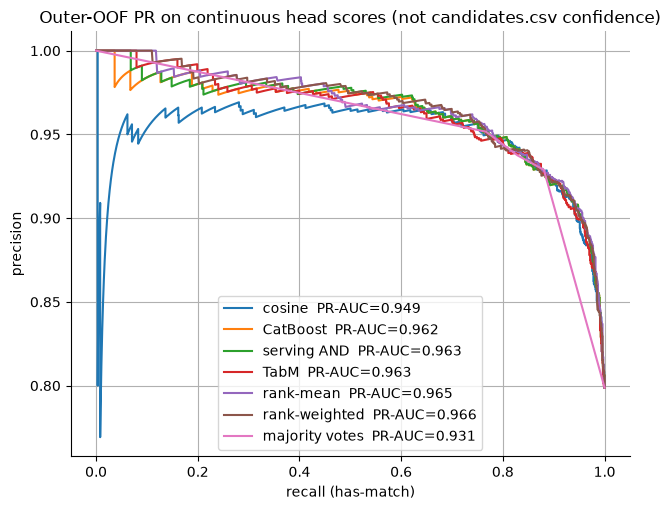

In [8]:
fig, ax = plt.subplots(figsize=(6.5, 5.2))
for name, title in (
    ("cosine", "cosine"),
    ("catboost", "CatBoost"),
    ("serving_and", "serving AND"),
    ("tabm", "TabM"),
    ("rank_mean", "rank-mean"),
    ("rank_weighted", "rank-weighted"),
    ("majority", "majority votes"),
):
    y = OOF[name]["y"]
    s = OOF[name]["scores"]
    p, r, _ = precision_recall_curve(y, s)
    ap = ranking_metrics(y, s)["pr_auc"]
    ax.plot(r, p, label=f"{title}  PR-AUC={ap:.3f}")
ax.set_xlabel("recall (has-match)")
ax.set_ylabel("precision")
ax.set_title("Outer-OOF PR on continuous head scores (not candidates.csv confidence)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "pr_curves.png", dpi=140, bbox_inches="tight")
plt.show()

Saved figure:

![PR curves](refusal_analysis_figs/pr_curves.png)


## Head-to-head, with ensembles last


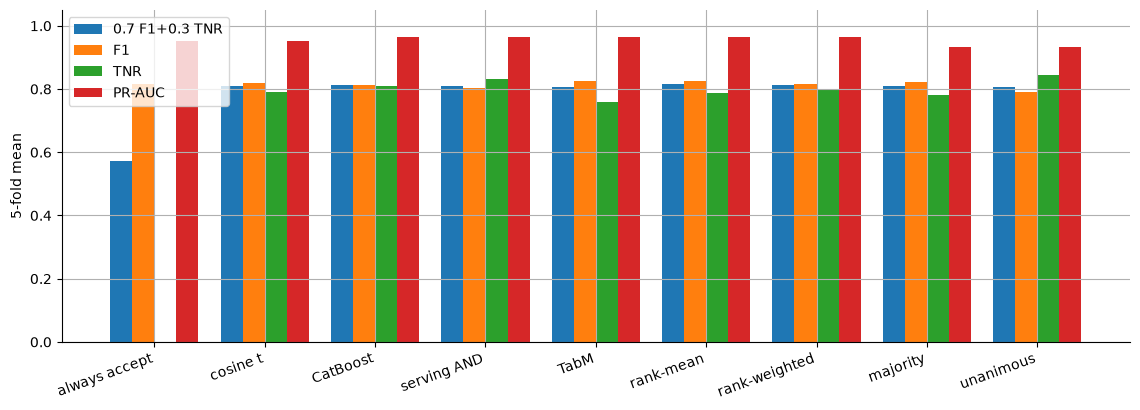

In [9]:
fig, ax = plt.subplots(figsize=(11.5, 4.2))
methods = order
labels = [
    "always accept",
    "cosine t",
    "CatBoost",
    "serving AND",
    "TabM",
    "rank-mean",
    "rank-weighted",
    "majority",
    "unanimous",
]
x = np.arange(len(methods))
width = 0.2
means = table.groupby("method")[["contest", "f1", "tnr", "pr_auc"]].mean().loc[methods]
for i, metric in enumerate(("contest", "f1", "tnr", "pr_auc")):
    label = {"contest": "0.7 F1+0.3 TNR", "f1": "F1", "tnr": "TNR", "pr_auc": "PR-AUC"}[metric]
    ax.bar(x + (i - 1.5) * width, means[metric], width, label=label)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("5-fold mean")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "metrics_bars.png", dpi=140, bbox_inches="tight")
plt.show()

Saved figure:

![metrics bars](refusal_analysis_figs/metrics_bars.png)


## CatBoost statistics


           feature  importance
0             top1     18.4062
16         n_ge_07      4.2193
22     margin_rest      4.2048
1             top2      4.1434
14   query_to_mean      3.7790
11         entropy      3.4371
9        mean_top3      3.1957
6            std_k      1.8131
13    pairwise_std      1.7920
5           mean_k      1.2081
17         n_ge_09      1.2005
10       mean_top5      0.9590
4            gap13      0.9148
526          g_247      0.8137
8            min_k      0.8093


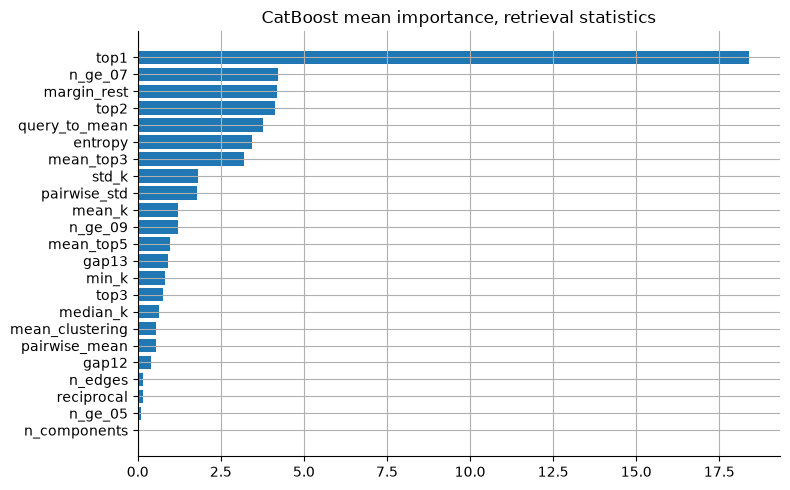

In [10]:
names = feature_names(FOLDS[0]["qe"].shape[1])
imps = np.stack([MODELS[fold]["catboost"].get_feature_importance() for fold in range(5)]).mean(0)
imp = pd.DataFrame({"feature": names, "importance": imps}).sort_values("importance", ascending=False)
display(imp.head(15))
stat_imp = imp[imp.feature.isin(STAT_NAMES)].copy()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(stat_imp.feature[::-1], stat_imp.importance[::-1])
ax.set_title("CatBoost mean importance, retrieval statistics")
fig.tight_layout()
fig.savefig(FIG_DIR / "catboost_stats.png", dpi=140, bbox_inches="tight")
plt.show()

Saved figure:

![CatBoost stats](refusal_analysis_figs/catboost_stats.png)


## Why the cosine threshold is 0.79

ArcFace (`m = 0.479` rad ≈ 27.4°, `s = 35.1`) and AdaSP (`τ = 0.026`, `1/τ ≈ 38`) do **not** algebraically fix an accept cut. AdaSP on PK 16×4 sees six positive pairs per identity and about 60 in-batch negatives; it enlarges the *gap* between a true match and a hard negative. Retrieval max-impostor is an extreme value over ~870 gallery crops, not those 60.

On the same 20% identity-hold-out packs: plot max cosine for closed queries vs open queries, the true-match max, and the best impostor. The contest cut is the midpoint of the two max-cosine distributions.


                 mean  median    p25
closed max     0.8568  0.8762 0.8214
true-match max 0.8450  0.8712 0.8070
impostor max   0.6638  0.6489 0.5634
open max       0.6710  0.6560 0.5750
intra pair     0.8056  0.8368 0.7550
serving t 0.7868  median midpoint 0.7661  mean midpoint 0.7639
gap mean 0.181  median 0.193  gap/tau 7.0  P(gap<0) 0.136
ArcFace m 27.4 deg  sqrt(E intra) 0.898  cos(theta+m) 0.593


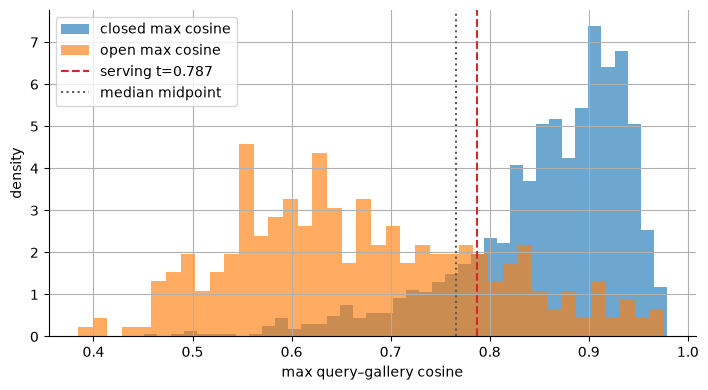

In [11]:
ARCFACE_M = 0.4789452160852028
ADASP_TAU = 0.026071235242105424
serving_t = float(np.mean(OOF["cosine"]["threshold"]))
closed_max, closed_true, closed_impostor, open_max, intra = [], [], [], [], []
for fold, pack in FOLDS.items():
    qids = pack["query"].vehicle_id.to_numpy()
    gids = pack["gallery"].vehicle_id.to_numpy()
    sim = similarities(pack["qe"], pack["ge"])
    _, keep, _held = open_set_split(qids, gids, fraction=OPEN_SET_FRACTION, seed=fold)
    sim_e = sim[:, keep]
    gids_e = gids[keep]
    for i in range(len(qids)):
        row = sim_e[i]
        same = gids_e == qids[i]
        if same.any():
            closed_max.append(float(row.max()))
            closed_true.append(float(row[same].max()))
            closed_impostor.append(float(row[~same].max()))
            intra.extend(row[same].astype(np.float64).tolist())
        else:
            open_max.append(float(row.max()))
closed_max = np.asarray(closed_max)
closed_true = np.asarray(closed_true)
closed_impostor = np.asarray(closed_impostor)
open_max = np.asarray(open_max)
intra = np.asarray(intra)
gap = closed_true - closed_impostor
display(
    pd.DataFrame(
        {
            "mean": [
                closed_max.mean(),
                closed_true.mean(),
                closed_impostor.mean(),
                open_max.mean(),
                intra.mean(),
            ],
            "median": [
                np.median(closed_max),
                np.median(closed_true),
                np.median(closed_impostor),
                np.median(open_max),
                np.median(intra),
            ],
            "p25": [
                np.quantile(closed_max, 0.25),
                np.quantile(closed_true, 0.25),
                np.quantile(closed_impostor, 0.25),
                np.quantile(open_max, 0.25),
                np.quantile(intra, 0.25),
            ],
        },
        index=pd.Index(["closed max", "true-match max", "impostor max", "open max", "intra pair"]),
    )
)
print(
    f"serving t {serving_t:.4f}  median midpoint {(np.median(closed_max) + np.median(open_max)) / 2:.4f}  "
    f"mean midpoint {(closed_max.mean() + open_max.mean()) / 2:.4f}"
)
print(
    f"gap mean {gap.mean():.3f}  median {np.median(gap):.3f}  gap/tau {gap.mean() / ADASP_TAU:.1f}  "
    f"P(gap<0) {float((gap < 0).mean()):.3f}"
)
print(
    f"ArcFace m {np.degrees(ARCFACE_M):.1f} deg  sqrt(E intra) {float(np.sqrt(intra.mean())):.3f}  "
    f"cos(theta+m) {float(np.cos(np.arccos(np.clip(np.sqrt(intra.mean()), 0, 1)) + ARCFACE_M)):.3f}"
)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.hist(closed_max, bins=40, density=True, alpha=0.65, label="closed max cosine")
ax.hist(open_max, bins=40, density=True, alpha=0.65, label="open max cosine")
ax.axvline(serving_t, color="C3", ls="--", label=f"serving t={serving_t:.3f}")
ax.axvline(
    (np.median(closed_max) + np.median(open_max)) / 2,
    color="0.35",
    ls=":",
    label="median midpoint",
)
ax.set_xlabel("max query–gallery cosine")
ax.set_ylabel("density")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "cosine_threshold_geometry.png", dpi=140, bbox_inches="tight")
plt.show()

Saved figure:

![cosine threshold geometry](refusal_analysis_figs/cosine_threshold_geometry.png)


## Holdout-seed sensitivity

GroupKFold stays. The 20% identity hold-out inside each val fold is one RNG draw (`seed=fold` in
the nested protocol). The cells below re-draw that hold-out on eight fixed seeds `{0..7}` and
report both a **re-fit** contest cut and the **frozen serving** cosine threshold (mean inner-CV
cut). Spread here is “was seed=fold a lucky open-set draw,” not a new test set.


In [12]:
from modules.quality import bbox_area, brightness, sharpness
from refusal import (
    HOLD_SEEDS,
    TEST_GALLERY_SIZE,
    bootstrap_accept_ci,
    candidate_metrics,
    cosine_holdout_sweep,
    identity_n_cameras,
    lookalike_mask,
    multi_camera_mask,
    open_set_sized_pack,
    paired_accept_delta_ci,
    percentile_mask,
    select_threshold,
    summarize_sweep,
)

SERVE_T = float(np.mean(OOF["cosine"]["threshold"]))
IMAGES = ROOT / "data" / "images"
hold_rows = []
for fold, pack in FOLDS.items():
    part = cosine_holdout_sweep(
        pack["qe"],
        pack["ge"],
        pack["query"].vehicle_id.to_numpy(),
        pack["gallery"].vehicle_id.to_numpy(),
        seeds=HOLD_SEEDS,
        frozen_threshold=SERVE_T,
    )
    for row in part:
        row["fold"] = fold
        hold_rows.append(row)
hold = pd.DataFrame(hold_rows)
display(hold.groupby("seed")[["fit_threshold", "fit_contest", "frozen_contest"]].mean())
keys = ("fit_threshold", "fit_f1", "fit_tnr", "fit_contest", "frozen_contest")
print("pooled over folds×seeds", summarize_sweep(hold_rows, keys))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
seed_t = [hold.loc[hold.seed == s, "fit_threshold"] for s in HOLD_SEEDS]
seed_c = [hold.loc[hold.seed == s, "frozen_contest"] for s in HOLD_SEEDS]
axes[0].boxplot(seed_t, tick_labels=list(HOLD_SEEDS))
axes[0].axhline(SERVE_T, color="black", ls="--")
axes[0].set_title("re-fit cosine threshold")
axes[0].set_xlabel("holdout seed")
axes[1].boxplot(seed_c, tick_labels=list(HOLD_SEEDS))
axes[1].set_title("frozen cosine cut, contest score")
axes[1].set_xlabel("holdout seed")
fig.savefig(FIG_DIR / "holdout_seeds.png", dpi=140, bbox_inches="tight")
plt.close(fig)
print("wrote", FIG_DIR / "holdout_seeds.png")

      fit_threshold  fit_contest  frozen_contest
seed                                            
0            0.7887       0.8244          0.8174
1            0.7676       0.8263          0.8149
2            0.7617       0.8320          0.8222
3            0.7705       0.8348          0.8208
4            0.7740       0.8247          0.8140
5            0.7607       0.8130          0.7996
6            0.7592       0.8172          0.8055
7            0.7525       0.8226          0.8096
pooled over folds×seeds {'fit_threshold': {'mean': 0.7668617442250252, 'std': 0.026894022176442364, 'min': 0.6909537315368652, 'max': 0.8222466111183167}, 'fit_f1': {'mean': 0.8388067257921531, 'std': 0.017306347022357, 'min': 0.8101851851851852, 'max': 0.8771929824561403}, 'fit_tnr': {'mean': 0.790725806451613, 'std': 0.06168036966556835, 'min': 0.6774193548387096, 'max': 0.9193548387096774}, 'fit_contest': {'mean': 0.8243824499899908, 'std': 0.01842376098152461, 'min': 0.7945896745066626, 'max': 0.87195

## Identity bootstrap CIs

Outer-OOF contest 0.810 (cosine) vs 0.812 (CatBoost) on 1541 queries. The next cell
resamples **queries/identities** with replacement from the concatenated outer-OOF decisions (the
same micro F1/TNR as the nested table). If the paired delta CI contains 0, cosine is still the
right serving choice because it is simpler, not because the gap is statistically clear.


In [13]:
N_BOOT = 2000
cos_ci = bootstrap_accept_ci(
    OOF["cosine"]["y"], OOF["cosine"]["accept"], OOF["cosine"]["top"], n_boot=N_BOOT, seed=0
)
cb_ci = bootstrap_accept_ci(
    OOF["catboost"]["y"], OOF["catboost"]["accept"], OOF["catboost"]["top"], n_boot=N_BOOT, seed=0
)
and_ci = bootstrap_accept_ci(
    OOF["serving_and"]["y"], OOF["serving_and"]["accept"], OOF["serving_and"]["top"], n_boot=N_BOOT, seed=0
)
delta = paired_accept_delta_ci(
    OOF["cosine"]["y"],
    OOF["cosine"]["top"],
    OOF["cosine"]["accept"],
    OOF["catboost"]["accept"],
    n_boot=N_BOOT,
    seed=0,
)
ci_tbl = pd.DataFrame(
    [
        {
            "head": "cosine",
            "f1": cos_ci["f1"]["point"],
            "tnr": cos_ci["tnr"]["point"],
            "contest": cos_ci["contest"]["point"],
            "contest_lo": cos_ci["contest"]["lo"],
            "contest_hi": cos_ci["contest"]["hi"],
        },
        {
            "head": "catboost",
            "f1": cb_ci["f1"]["point"],
            "tnr": cb_ci["tnr"]["point"],
            "contest": cb_ci["contest"]["point"],
            "contest_lo": cb_ci["contest"]["lo"],
            "contest_hi": cb_ci["contest"]["hi"],
        },
        {
            "head": "AND",
            "f1": and_ci["f1"]["point"],
            "tnr": and_ci["tnr"]["point"],
            "contest": and_ci["contest"]["point"],
            "contest_lo": and_ci["contest"]["lo"],
            "contest_hi": and_ci["contest"]["hi"],
        },
    ]
)
display(ci_tbl)
print("cosine - catboost contest delta", delta)
fig, ax = plt.subplots()
ys = np.arange(len(ci_tbl))
ax.hlines(ys, ci_tbl["contest_lo"], ci_tbl["contest_hi"], color="#3b6ea5")
ax.plot(ci_tbl["contest"], ys, "o", color="#3b6ea5")
ax.set_yticks(ys, ci_tbl["head"])
ax.set_xlabel("contest score")
ax.set_title("identity-bootstrap 95% CI")
fig.savefig(FIG_DIR / "contest_ci.png", dpi=140, bbox_inches="tight")
plt.close(fig)

       head     f1    tnr  contest  contest_lo  contest_hi
0    cosine 0.8191 0.7903   0.8105      0.7887      0.8304
1  catboost 0.8127 0.8097   0.8118      0.7911      0.8322
2       AND 0.8026 0.8323   0.8115      0.7914      0.8309
cosine - catboost contest delta {'point': -0.0013033083565169301, 'lo': -0.013504568800281546, 'hi': 0.010677348979783077, 'includes_zero': True, 'n': 1541, 'n_boot': 2000}


## Gallery size near the test

Max-cosine thresholds move with the number of negatives. The public gallery is 750. Each val fold
gallery is ~1100. After the 20% identity hold-out, the remaining gallery is subsampled to 750
(keeping at least one positive per closed identity). Frozen serving threshold is applied unchanged.


In [14]:
sized = []
for fold, pack in FOLDS.items():
    _x, y, cos, hit, held, keep = open_set_sized_pack(
        pack["qe"],
        pack["ge"],
        pack["query"].vehicle_id.to_numpy(),
        pack["gallery"].vehicle_id.to_numpy(),
        n_keep=TEST_GALLERY_SIZE,
        seed=fold,
    )
    fitted = select_threshold(y, cos, hit, kind="contest")
    frozen = candidate_metrics(y, cos, SERVE_T, hit)
    sized.append(
        {
            "fold": fold,
            "n_gallery": int(keep.sum()),
            "n_open": int((~np.asarray(y, dtype=bool)).sum()),
            "fit_threshold": fitted["threshold"],
            "fit_contest": fitted["contest"],
            "frozen_contest": frozen["contest"],
            "frozen_f1": frozen["f1"],
            "frozen_tnr": frozen["tnr"],
        }
    )
sized_tbl = pd.DataFrame(sized)
display(sized_tbl)
print(
    "mean frozen contest @750",
    float(sized_tbl.frozen_contest.mean()),
    "vs nested cosine contest 0.810 on the full val gallery",
)

   fold  n_gallery  n_open  fit_threshold  fit_contest  frozen_contest  frozen_f1  frozen_tnr
0     0        750      62         0.7870       0.8132          0.8132     0.7953      0.8548
1     1        750      62         0.7473       0.8049          0.7835     0.7945      0.7581
2     2        750      62         0.7828       0.8262          0.8204     0.8056      0.8548
3     3        750      62         0.7961       0.8258          0.8124     0.8288      0.7742
4     4        750      62         0.8222       0.8409          0.8284     0.8378      0.8065
mean frozen contest @750 0.8115886393320254 vs nested cosine contest 0.810 on the full val gallery


## Difficulty slices on the nested eval packs

Same a priori cuts as the OOF notebook, scored with the **frozen serving cosine threshold** on the
protocol eval pack (`seed=fold`). A slice can change F1 and TNR for different reasons: night/blur
hurt closed top-1 (more FP_closed / FN), lookalikes raise the impostor max (more FP_open if we
accept).


In [15]:
from PIL import Image

from dataset.images import crop_bbox, image_path


def crop_quality(frame):
    area = bbox_area(frame.w.to_numpy(), frame.h.to_numpy())
    bright, sharp = [], []
    for row in frame.itertuples(index=False):
        path = image_path(IMAGES, row.image_id)
        with Image.open(path) as im:
            crop = [row.x, row.y, row.w, row.h]
            rgb = np.asarray(crop_bbox(im.convert("RGB"), crop, 0))
        bright.append(brightness(rgb))
        sharp.append(sharpness(rgb))
    return area, np.asarray(bright), np.asarray(sharp)


slice_rows = []
for fold, pack in FOLDS.items():
    q = pack["query"]
    g = pack["gallery"]
    y = EVAL[fold]["y"].astype(bool)
    cos = EVAL[fold]["cos"]
    top = EVAL[fold]["top"]
    area, bright, sharp = crop_quality(q)
    oof = pd.concat([q, g], ignore_index=True)
    cams = identity_n_cameras(oof.vehicle_id, oof.camera_id)
    sim = similarities(pack["qe"], pack["ge"])
    look = lookalike_mask(sim, q.vehicle_id.to_numpy(), g.vehicle_id.to_numpy(), 0.55)
    masks = {
        "all": np.ones(len(q), dtype=bool),
        "small bbox": percentile_mask(area, 25, "low"),
        "night": percentile_mask(bright, 25, "low"),
        "blur": percentile_mask(sharp, 25, "low"),
        "multi-camera": multi_camera_mask(q.vehicle_id, cams, min_cameras=3),
        "lookalike": look,
    }
    for name, mask in masks.items():
        if int(mask.sum()) < 8:
            continue
        row = candidate_metrics(y[mask], cos[mask], SERVE_T, top[mask])
        slice_rows.append({"fold": fold, "slice": name, **row})
slicet = pd.DataFrame(slice_rows)
agg = slicet.groupby("slice")[["contest", "f1", "tnr", "n"]].mean()
display(agg.sort_values("contest"))
fig, ax = plt.subplots()
order = agg.sort_values("contest")
ax.barh(order.index.astype(str), order["contest"], color="#3b6ea5")
ax.set_xlabel("mean fold contest score at cosine cut")
ax.set_title("refusal difficulty slices")
fig.savefig(FIG_DIR / "refusal_slices.png", dpi=140, bbox_inches="tight")
plt.close(fig)

/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/data/projects/ryzhichkin/ReID/.venv/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


              contest     f1    tnr        n
slice                                       
blur           0.7831 0.7900 0.7671  77.2000
night          0.7923 0.8070 0.7580  77.2000
lookalike      0.7982 0.8110 0.7682 258.2000
all            0.8148 0.8211 0.8000 308.2000
multi-camera   0.8276 0.8546 0.7645 102.6000
small bbox     0.8294 0.8322 0.8228  77.2000


## Control protocol and full-retrain

Nested 5-fold refusal inner-CV does **not** undo HPO leakage: the embeddings themselves were
selected on these folds. The per-fold outer scores are the local control. Serving applies the mean
inner-CV cosine threshold to a **full-retrain** extractor that has seen every labeled identity.
OOF F1/TNR are not a direct measurement of that checkpoint on new identities. On defense that gap
has to be named: OOF calibrates the rule; the hidden test is a different identity pool and a 750
image gallery.


In [16]:
fold_ctrl = table[table.method == "cosine"][["fold", "contest", "f1", "tnr", "threshold"]]
display(fold_ctrl)
print("cosine fold contest std", float(fold_ctrl.contest.std(ddof=0)))
print("serving threshold (mean inner-CV)", SERVE_T)
print("OOF metrics are fold extractors; serving weights are full-retrain last.ckpt EMA")

    fold  contest     f1    tnr  threshold
1      0   0.8050 0.7906 0.8387     0.7935
10     1   0.7813 0.7982 0.7419     0.7876
19     2   0.8258 0.8203 0.8387     0.7854
28     3   0.8136 0.8374 0.7581     0.7846
37     4   0.8252 0.8470 0.7742     0.7828
cosine fold contest std 0.01637857066317523
serving threshold (mean inner-CV) 0.7868064761161804
OOF metrics are fold extractors; serving weights are full-retrain last.ckpt EMA


## Takeaway

- CatBoost and TabM still train on 50/50 stripped-identity pairs. Thresholds, F1, TNR, and outer-OOF use a separate 20% identity-hold-out pack (`open_set_pack`), matching hidden-test prevalence.
- The operating point maximizes the contest score `0.7 × F1 + 0.3 × TNR` on inner-CV **eval** scores. max-F1 alone can pick a point with TNR 0.
- Contest F1 is query-level: TP = has match and top-1 identity is correct. Extra candidates do not count as extra FP. Closed wrong top-1 is FP (`fp_closed`).
- TNR uses only no-match queries. Always-accept still has TNR 0.
- Outer-OOF accept/refuse uses each fold's own inner-CV threshold. Serving cosine/CatBoost thresholds are the mean of those five inner points, not a threshold fit on the evaluated queries.
- **Docker is CatBoost** (`eva02_model`), not `serving_and`. `serving_and` accepts only when frozen cosine AND CatBoost both accept. Rank-average / majority / unanimous stay OOF calibration only.
- Hidden-test prevalence is ~20% open. Local eval packs hold out 20% of identities from the gallery, so the reported F1/TNR are not the old 50/50 probe.
- Eight fixed open-set hold-out seeds `{0..7}` on every fold: re-fit cosine cuts average **0.767** (std 0.027). Frozen cosine cut 0.7868 scores contest **0.813 mean** (std 0.019). Seed=`fold` was not a uniquely lucky draw.
- Identity-bootstrap 95% CI on nested outer-OOF: cosine contest **0.810 [0.789, 0.830]**, CatBoost **0.812 [0.791, 0.832]**, AND **0.812 [0.791, 0.831]**. Paired cosine−CatBoost delta **−0.001 [−0.014, 0.011] includes 0**. CatBoost still wins the point estimate and stays the Docker head (P ≥ 0.5873, `eva02_model`).
- Gallery subsampled to **750** after the 20% identity hold-out: frozen-cut contest **0.812** vs 0.810 on the full val gallery.
- Fold contest std for cosine is **0.016**. Serving thresholds are mean inner-CV cuts: cosine **0.7868**, CatBoost **0.5873**.
